## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf as pacf_vals_fn
import seaborn as sns

In [2]:
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectFromModel
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import matplotlib.gridspec as gridspec
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
from sklearn.utils import shuffle

## Consumindo base de dados

In [4]:
url = r'C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\INTERNACOES_x_QUALIAR.csv'

df_qualiar_int = pd.read_csv(url)

display(df_qualiar_int.head())

,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,AQI,Qualidade_do_Ar,num_internacoes,internacoes_d1,internacoes_d7
0,2012-01-01,2012,1,1,1.693921,-0.051742,1.917484,0.693390,-1.964227,-0.759897,-1.150568,-0.822666,-0.917604,-0.869809,0.035735,-1.477106,1.0,507,728.0,390.0
1,2012-01-02,2012,1,2,1.816431,-0.943870,2.236553,-0.302832,0.226355,-0.371044,-0.168446,-1.346559,-1.232715,-2.319570,-1.367160,-2.071418,1.0,728,429.0,442.0
2,2012-01-03,2012,1,3,-0.766991,-0.315602,0.424084,-0.778747,0.702674,-0.216149,0.184335,-0.217835,-1.762871,-0.854360,-1.570305,-1.235923,1.0,429,416.0,546.0
3,2012-01-04,2012,1,4,-0.698032,-0.000874,0.122627,-0.612457,1.238748,0.753858,1.036985,-0.588549,-0.720611,0.202152,0.150301,-0.029610,1.0,416,403.0,494.0
4,2012-01-05,2012,1,5,-0.839592,0.145484,0.365842,-0.656019,0.654600,0.333601,0.472384,-0.617587,0.063417,-0.020606,-0.398419,0.137534,1.0,403,520.0,468.0


In [5]:
df_internacoes_d1 = df_qualiar_int.drop(['internacoes_d7'], axis=1)
df_internacoes_d7 = df_qualiar_int.drop(['internacoes_d1'], axis=1)

## Prevendo internações de amanha (D1)

### Criando features

In [7]:
df_internacoes_d1['lag_0'] = df_internacoes_d1['num_internacoes'].shift(0)
df_internacoes_d1['lag_1'] = df_internacoes_d1['num_internacoes'].shift(1)
df_internacoes_d1['lag_2'] = df_internacoes_d1['num_internacoes'].shift(2)
df_internacoes_d1['lag_3'] = df_internacoes_d1['num_internacoes'].shift(3)
df_internacoes_d1['lag_4'] = df_internacoes_d1['num_internacoes'].shift(4)
df_internacoes_d1['lag_5'] = df_internacoes_d1['num_internacoes'].shift(5)
df_internacoes_d1['internacoes_ma14'] = df_internacoes_d1['num_internacoes'].rolling(window=14).mean().shift(1)

# Criação das versões das variáveis conforme especificação
df_internacoes_d1['o3_ma150'] = df_internacoes_d1['o3'].rolling(window=150).mean().shift(0)
df_internacoes_d1['no_ma60_s3'] = df_internacoes_d1['no'].rolling(window=60).mean().shift(3)
df_internacoes_d1['nox_ma60_s3'] = df_internacoes_d1['nox'].rolling(window=60).mean().shift(3)
df_internacoes_d1['no2_ma60'] = df_internacoes_d1['no2'].rolling(window=60).mean().shift(0)
df_internacoes_d1['pm10_ma60'] = df_internacoes_d1['pm10'].rolling(window=60).mean().shift(0)
df_internacoes_d1['temp_ma14'] = df_internacoes_d1['temp'].rolling(window=14).mean().shift(0)
df_internacoes_d1['so2_ma150_s9'] = df_internacoes_d1['so2'].rolling(window=150).mean().shift(9)

In [8]:
df_internacoes_d1.drop(columns=['ano', 'mes',	'dia', 'chuva', 'co', 'no', 'no2', 'nox', 'o3', 'pm10', 'pm2_5', 'so2', 'temp', 'ur', 'AQI', 'Qualidade_do_Ar', 'num_internacoes'], inplace=True)

In [9]:
display(df_internacoes_d1.head())

,data_dia,internacoes_d1,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,internacoes_ma14,o3_ma150,no_ma60_s3,nox_ma60_s3,no2_ma60,pm10_ma60,temp_ma14,so2_ma150_s9
0,2012-01-01,728.0,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-02,429.0,728,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-01-03,416.0,429,728.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-01-04,403.0,416,429.0,728.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-01-05,520.0,403,416.0,429.0,728.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# TEste

In [10]:
def create_sequences(data, target, n_steps):
    X_seq, y_seq = [], []

    # Verificação de consistência
    assert len(data) == len(target), "Dados e alvo têm tamanhos diferentes!"

    for i in range(n_steps, len(data)):
        X_seq.append(data[i - n_steps:i])      # janela de n_steps
        y_seq.append(target[i])                # alvo futuro (no tempo i)

    return np.array(X_seq), np.array(y_seq)

def calcular_metricas(y_true, y_pred):
    return {
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE': round(mean_absolute_error(y_true, y_pred), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 2)
    }

In [11]:
def criar_modelo_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return model

In [12]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import numpy as np

def treinar_lstm_model(df, target, n_steps=30, n_splits=5):
    print(f"Treinando modelo LSTM para {target}")

    features = [col for col in df.columns if col not in ['data_dia', 'classificacao',
        'num_internacoes', 'internacoes_d1', 'internacoes_d7', target]]

    X = df[features].values
    y = df[target].values
    y_log = np.log1p(y)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y_log, n_steps)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    train_index, test_index = list(tscv.split(X_seq))[-1]

    X_train, X_test = X_seq[train_index], X_seq[test_index]
    y_train, y_test = y_seq[train_index], y_seq[test_index]

    test_idx = np.arange(len(y_seq))[test_index]

    model = criar_modelo_lstm((n_steps, X_train.shape[2]))
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[
            EarlyStopping(patience=15, restore_best_weights=True),
            ReduceLROnPlateau(factor=0.5, patience=5)
        ],
        verbose=1
    )

    return model, history, X_test, y_test, test_idx, y_seq, df

In [13]:
def avaliar_lstm(model, history, X_test, y_test, test_idx, y_seq, df, n_steps=14, max_points=150):
    y_pred = np.expm1(model.predict(X_test).flatten())
    y_true = np.expm1(y_test)
    dates = df.iloc[test_idx + n_steps]['data_dia'].values
    resultados = calcular_metricas(y_true, y_pred)

    print(f"\n Chart 1: Last {max_points} points (sequential index)")
    idx_ini = max(0, len(y_true) - max_points)
    x = np.arange(len(y_true))[idx_ini:]
    y_true_plot = y_true[idx_ini:]
    y_pred_plot = y_pred[idx_ini:]

    plt.figure(figsize=(14, 5))
    plt.plot(x, y_true_plot, label="Actual", marker='o')
    plt.plot(x, y_pred_plot, label="LSTM", linestyle='--', marker='s')
    plt.fill_between(x, y_true_plot, y_pred_plot, color='gray', alpha=0.2)
    plt.title(f"LSTM Predictions vs Actual Values (last {max_points})")
    plt.xlabel("Index")
    plt.ylabel("Hospitalizations")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(" Chart 3: Loss curves")
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Training')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title("LSTM Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("\nLSTM Metrics:")
    for metric, value in resultados.items():
        unit = "%" if "MAPE" in metric else ""
        print(f" - {metric:<10}: {value:.2f}{unit}")

    return resultados


In [14]:
df_internacoes_d1.dropna(inplace=True)

model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq = treinar_lstm_model(df_internacoes_d1, 'internacoes_d1')

Treinando modelo LSTM para internacoes_d1
Epoch 1/100


c:\Users\jhter\OneDrive - cefet-rj.br\qualiar\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - loss: 2.9267 - val_loss: 0.5385 - learning_rate: 0.0010
Epoch 2/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.1381 - val_loss: 0.4467 - learning_rate: 0.0010
Epoch 3/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - loss: 0.1035 - val_loss: 0.4128 - learning_rate: 0.0010
Epoch 4/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - loss: 0.0961 - val_loss: 0.3567 - learning_rate: 0.0010
Epoch 5/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0913 - val_loss: 0.3469 - learning_rate: 0.0010
Epoch 6/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0851 - val_loss: 0.3215 - learning_rate: 0.0010
Epoch 7/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.0805 - val_loss: 0.3296 - learning_rate: 0.0010
Epoch 8/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0801 - val_loss: 0.3245 - learning_rate: 0.0010
Epoch 9/100
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0780 - val_loss: 0.3108 - learning_rate: 0.0010
Epoch 10/100
94/94 ━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step

 Chart 1: Last 150 points (sequential index)


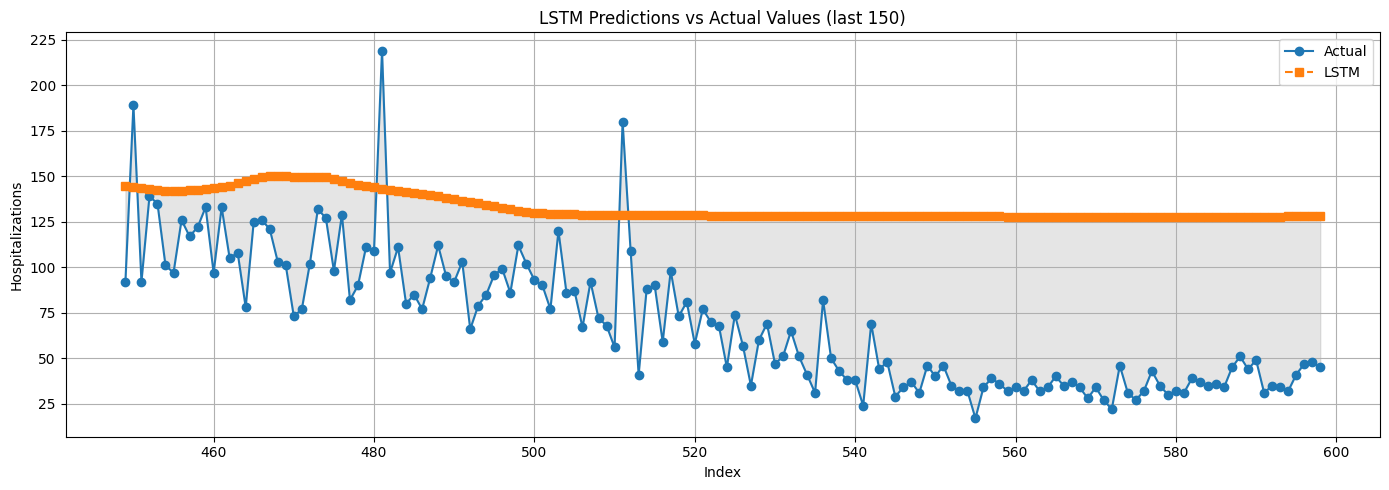

 Chart 3: Loss curves


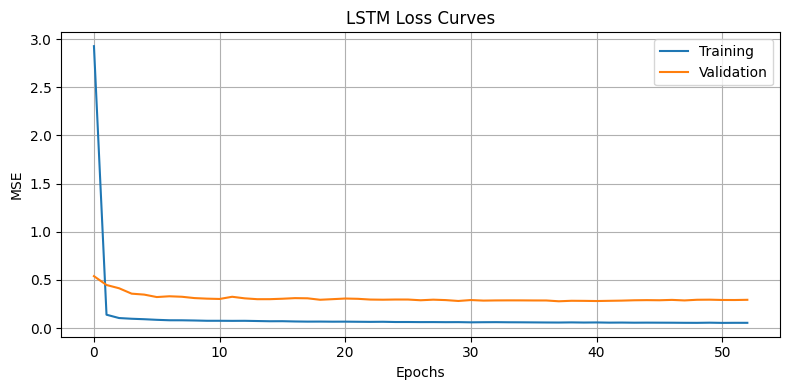


LSTM Metrics:
 - RMSE      : 56.21
 - MAE       : 45.73
 - MAPE (%)  : 56.46%


{'RMSE': np.float64(56.21), 'MAE': 45.73, 'MAPE (%)': 56.46}

In [15]:
avaliar_lstm(model_lstm, hist_lstm, X_test_lstm, y_test_lstm, test_idx_lstm, y_seq_lstm, df_seq)
